In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [20]:
df = pd.read_csv("edu.csv")
df.head()

,country,date,GNP,Population,Edu_prime,Edu_second,Edu_post_second,Edu_lower_second,Unemp,c_codes
0,ARAB WORLD,2017,16997.503539,414491886.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ARAB WORLD,2016,16794.064949,406452690.0,83.911949,NaN,NaN,NaN,NaN,NaN
2,ARAB WORLD,2015,16366.596405,398304960.0,84.720306,NaN,NaN,NaN,NaN,NaN
3,ARAB WORLD,2014,15895.251480,390043028.0,85.314812,NaN,NaN,NaN,NaN,NaN
4,ARAB WORLD,2013,15453.220686,381702086.0,84.703484,NaN,NaN,NaN,NaN,NaN


In [21]:
print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns)

print("\nValeurs manquantes :")
print(df.isnull().sum())

Dimensions : (15312, 10)

Colonnes :
Index(['country', 'date', 'GNP', 'Population', 'Edu_prime', 'Edu_second',
       'Edu_post_second', 'Edu_lower_second', 'Unemp', 'c_codes'],
      dtype='object')

Valeurs manquantes :
country                 0
date                    0
GNP                  9035
Population            165
Edu_prime            8871
Edu_second          14442
Edu_post_second     14522
Edu_lower_second    14336
Unemp               13620
c_codes              4756
dtype: int64


In [22]:
edu_cols = [
    'Edu_prime',
    'Edu_second',
    'Edu_post_second',
    'Edu_lower_second'
]

work = df[['country', 'date', 'GNP', 'Population', 'Unemp'] + edu_cols].copy()
work.head()

,country,date,GNP,Population,Unemp,Edu_prime,Edu_second,Edu_post_second,Edu_lower_second
0,ARAB WORLD,2017,16997.503539,414491886.0,NaN,NaN,NaN,NaN,NaN
1,ARAB WORLD,2016,16794.064949,406452690.0,NaN,83.911949,NaN,NaN,NaN
2,ARAB WORLD,2015,16366.596405,398304960.0,NaN,84.720306,NaN,NaN,NaN
3,ARAB WORLD,2014,15895.251480,390043028.0,NaN,85.314812,NaN,NaN,NaN
4,ARAB WORLD,2013,15453.220686,381702086.0,NaN,84.703484,NaN,NaN,NaN


In [23]:
for col in work.columns:
    if col != 'country':
        work[col] = pd.to_numeric(work[col], errors='coerce')

# supprimer les lignes inutilisables
work = work.dropna(subset=['Unemp'])
work = work.dropna(subset=edu_cols, how='all')

print(work.shape)
work.head()

(1280, 9)


,country,date,GNP,Population,Unemp,Edu_prime,Edu_second,Edu_post_second,Edu_lower_second
117,CENTRAL EUROPE AND THE BALTICS,2016,25864.197405,102994343.0,3.933578,97.066704,NaN,NaN,NaN
118,CENTRAL EUROPE AND THE BALTICS,2015,24919.177896,103257751.0,4.717307,97.056419,NaN,NaN,NaN
119,CENTRAL EUROPE AND THE BALTICS,2014,24175.666952,103496179.0,5.628115,96.268730,NaN,NaN,NaN
120,CENTRAL EUROPE AND THE BALTICS,2013,23269.576545,103713726.0,6.318042,96.559273,NaN,NaN,NaN
121,CENTRAL EUROPE AND THE BALTICS,2012,22231.158377,103935318.0,6.071406,96.144051,NaN,NaN,NaN


In [24]:
work['dominant_level'] = work[edu_cols].idxmax(axis=1)

work[['country', 'dominant_level', 'Unemp']].head()

,country,dominant_level,Unemp
117,CENTRAL EUROPE AND THE BALTICS,Edu_prime,3.933578
118,CENTRAL EUROPE AND THE BALTICS,Edu_prime,4.717307
119,CENTRAL EUROPE AND THE BALTICS,Edu_prime,5.628115
120,CENTRAL EUROPE AND THE BALTICS,Edu_prime,6.318042
121,CENTRAL EUROPE AND THE BALTICS,Edu_prime,6.071406


In [25]:
summary = work.groupby('dominant_level')['Unemp'].agg(['count', 'mean', 'median'])
summary = summary.sort_values('mean')

summary

,count,mean,median
dominant_level,,,
Edu_post_second,2,4.288350,4.288350
Edu_lower_second,202,5.482632,4.298000
Edu_second,14,6.405336,4.128050
Edu_prime,1062,7.782109,5.565084


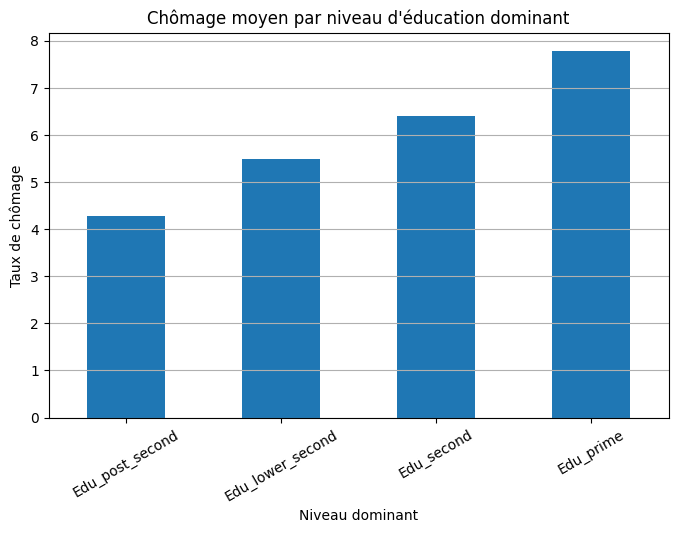

In [26]:
plt.figure(figsize=(8,5))
summary['mean'].plot(kind='bar')

plt.title("Chômage moyen par niveau d'éducation dominant")
plt.ylabel("Taux de chômage")
plt.xlabel("Niveau dominant")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()

In [27]:
groups = [group['Unemp'].values for _, group in work.groupby('dominant_level')]

anova = stats.f_oneway(*groups)

print("F-statistic :", anova.statistic)
print("P-value :", anova.pvalue)

F-statistic : 6.248835776884709
P-value : 0.00032799342349416536


In [28]:
if anova.pvalue < 0.05:
    print("✅ Différence significative entre les groupes")
else:
    print("❌ Pas de différence significative")

✅ Différence significative entre les groupes


In [29]:
corr = work[edu_cols + ['Unemp', 'GNP']].corr()

corr['Unemp'].sort_values(ascending=False)

,Unemp
Unemp,1.000000
Edu_post_second,-0.186427
Edu_second,-0.265609
Edu_prime,-0.267633
Edu_lower_second,-0.292943
GNP,-0.336226


In [30]:
print("""
Conclusion :
Le test ANOVA montre que le niveau d'éducation dominant
influence significativement le taux de chômage.
Les pays avec plus d'éducation post-secondaire
présentent généralement un chômage plus faible.
""")


Conclusion :
Le test ANOVA montre que le niveau d'éducation dominant
influence significativement le taux de chômage.
Les pays avec plus d'éducation post-secondaire
présentent généralement un chômage plus faible.

